# DeepAR Generative Futures — Using DeepAR as a Generative Model

> **Área:** Séries Temporais  
> **Tarefa:** Geração de futuros alternativos (forecasting probabilístico intensivo)  
> **Modelo:** DeepAR (GluonTS/PyTorch) — Salinas et al., 2020  
> **Abordagem:** Treina DeepAR e gera **500 trajetórias futuras** por dataset, tratando o modelo como gerador de cenários  
> **Datasets:** CO₂ Mauna Loa (~2000 obs semanais) e Sintético (520 obs com regime changes + jumps)  
> **Status:** Concluído

Este notebook explora o **aspecto generativo** do DeepAR: ao invés de produzir uma única previsão,
o modelo gera centenas de futuros plausíveis, cada um consistente com os padrões aprendidos.
Isso permite:
- **Análise de cenários**: otimista, pessimista, volátil, mediano
- **Probabilidade de eventos**: P(valor > threshold), P(path cruza nível)
- **Distribuição completa** em cada passo futuro
- **Simulação de risco**: quantificar incerteza além de intervalos de confiança

## 1. Setup

In [1]:
import warnings; warnings.filterwarnings('ignore')
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

np.random.seed(42)
import torch; torch.manual_seed(42)

ARTIFACT_DIR = os.path.join('..', '..', 'artifacts', 'deepar_generative_futures')
os.makedirs(ARTIFACT_DIR, exist_ok=True)
NUM_SAMPLES = 500
print(f'GluonTS: {__import__("gluonts").__version__} | PyTorch: {torch.__version__} | CUDA: {torch.cuda.is_available()}')

GluonTS: 0.17.0 | PyTorch: 2.11.0+cpu | CUDA: False


## 2. Data Loading

In [2]:
def load_co2():
    from statsmodels.datasets.co2 import load_pandas
    df = load_pandas().data.resample('W').mean().interpolate().reset_index()
    df.columns = ['date','value']; df['value'] = pd.to_numeric(df['value'], errors='coerce')
    return df.dropna().sort_values('date').reset_index(drop=True)

def load_synthetic():
    np.random.seed(42); n = 520; t = np.arange(n)
    trend = np.where(t < 156, 300 + 0.05*t,
            np.where(t < 312, 300 + 0.05*155 + 0.10*(t-155),
                     300 + 0.05*155 + 0.10*156 + 0.02*(t-311)))
    seasonality = 5 * np.sin(2*np.pi*t/52)
    noise = np.random.normal(0, 4, n)
    jumps = np.zeros(n)
    for ji in range(20, n, 20):
        jumps[ji:ji+2] += np.random.choice([-10, 10, 15, -15])
    values = trend + seasonality + noise + jumps
    return pd.DataFrame({'date': pd.date_range('2010-01-01', periods=n, freq='W'), 'value': values})

for name, fn in [('CO2', load_co2), ('Synthetic', load_synthetic)]:
    df = fn()
    print(f'{name:12s}: {len(df):5d} obs, range=[{df["value"].min():.1f}, {df["value"].max():.1f}]')

CO2         :  2284 obs, range=[313.0, 373.9]
Synthetic   :   520 obs, range=[282.0, 346.0]


## 3. DeepAR Training & Generation

Treina o modelo e gera 500 trajetórias futuras. Cada trajetória é uma amostra da distribuição
preditiva aprendida — um "futuro possível" segundo o modelo.

In [3]:
FREQ_MAP = {'YS': 'Y', 'YE': 'Y'}

def train_deepar_generate(df, horizon, freq, num_samples=500, max_epochs=40):
    from gluonts.torch import DeepAREstimator
    from gluonts.torch.distributions import StudentTOutput
    from gluonts.dataset.pandas import PandasDataset
    from gluonts.evaluation import make_evaluation_predictions
    from lightning.pytorch.callbacks import EarlyStopping

    gluonts_freq = FREQ_MAP.get(freq, freq)
    df_ts = df[['date','value']].copy()
    df_ts['date'] = pd.to_datetime(df_ts['date'])
    df_ts = df_ts.set_index('date').sort_index(); df_ts.columns = ['y']
    if gluonts_freq == 'Y':
        df_ts.index = df_ts.index.to_period('Y')

    train_df = df_ts.iloc[:-horizon]
    train_ds = PandasDataset({'train': train_df}, target='y')
    context_length = max(horizon * 2, 10)

    estimator = DeepAREstimator(
        freq=gluonts_freq, prediction_length=horizon, context_length=context_length,
        batch_size=32, distr_output=StudentTOutput(), num_feat_dynamic_real=0,
        trainer_kwargs={
            'max_epochs': max_epochs,
            'callbacks': [EarlyStopping(monitor='val_loss', patience=12)],
            'enable_progress_bar': False, 'enable_model_summary': False,
            'logger': False, 'default_root_dir': os.path.join(ARTIFACT_DIR, 'checkpoints'),
        }, lr=1e-3)

    t0 = time.time()
    predictor = estimator.train(training_data=train_ds, validation_data=train_ds)
    train_time = time.time() - t0

    full_ds = PandasDataset({'full': df_ts}, target='y')
    forecast_it, ts_it = make_evaluation_predictions(
        dataset=full_ds, predictor=predictor, num_samples=num_samples)
    forecast = list(forecast_it)[0]
    ts_actual = list(ts_it)[0]
    samples = forecast.samples
    actual = ts_actual.values[-horizon:]

    last_train = df_ts.index[-horizon-1]
    if hasattr(last_train, 'to_timestamp'): last_train = last_train.to_timestamp()
    future_dates = pd.date_range(
        last_train + (pd.Timedelta(7,'D') if freq=='W' else pd.DateOffset(years=1)),
        periods=horizon, freq=freq)
    return samples, actual, future_dates, train_df.reset_index().rename(columns={'y': 'value'}), train_time

print('Functions ready.')

Functions ready.


## 4. CO₂ — 500 Futuros Gerados

In [4]:
df_co2 = load_co2()
samples_co2, actual_co2, future_co2, train_co2, time_co2 = train_deepar_generate(
    df_co2, horizon=30, freq='W', num_samples=NUM_SAMPLES, max_epochs=40)
print(f'CO2: {samples_co2.shape[0]} paths geradas em {time_co2:.1f}s')

GPU available: False, used: False


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Epoch 0, global step 50: 'val_loss' reached 4.80753 (best 4.80753), saving model to '..\\..\\artifacts\\deepar_generative_futures\\checkpoints\\checkpoints\\epoch=0-step=50.ckpt' as top 1


Epoch 1, global step 100: 'val_loss' was not in top 1


...

Epoch 34, global step 1750: 'val_loss' was not in top 1


Epoch 35, global step 1800: 'val_loss' was not in top 1


Epoch 36, global step 1850: 'val_loss' was not in top 1


Epoch 37, global step 1900: 'val_loss' was not in top 1


CO2: 500 paths geradas em 360.9s


### 4.1 Fan Chart — Envelope de Predição Multi-Nível

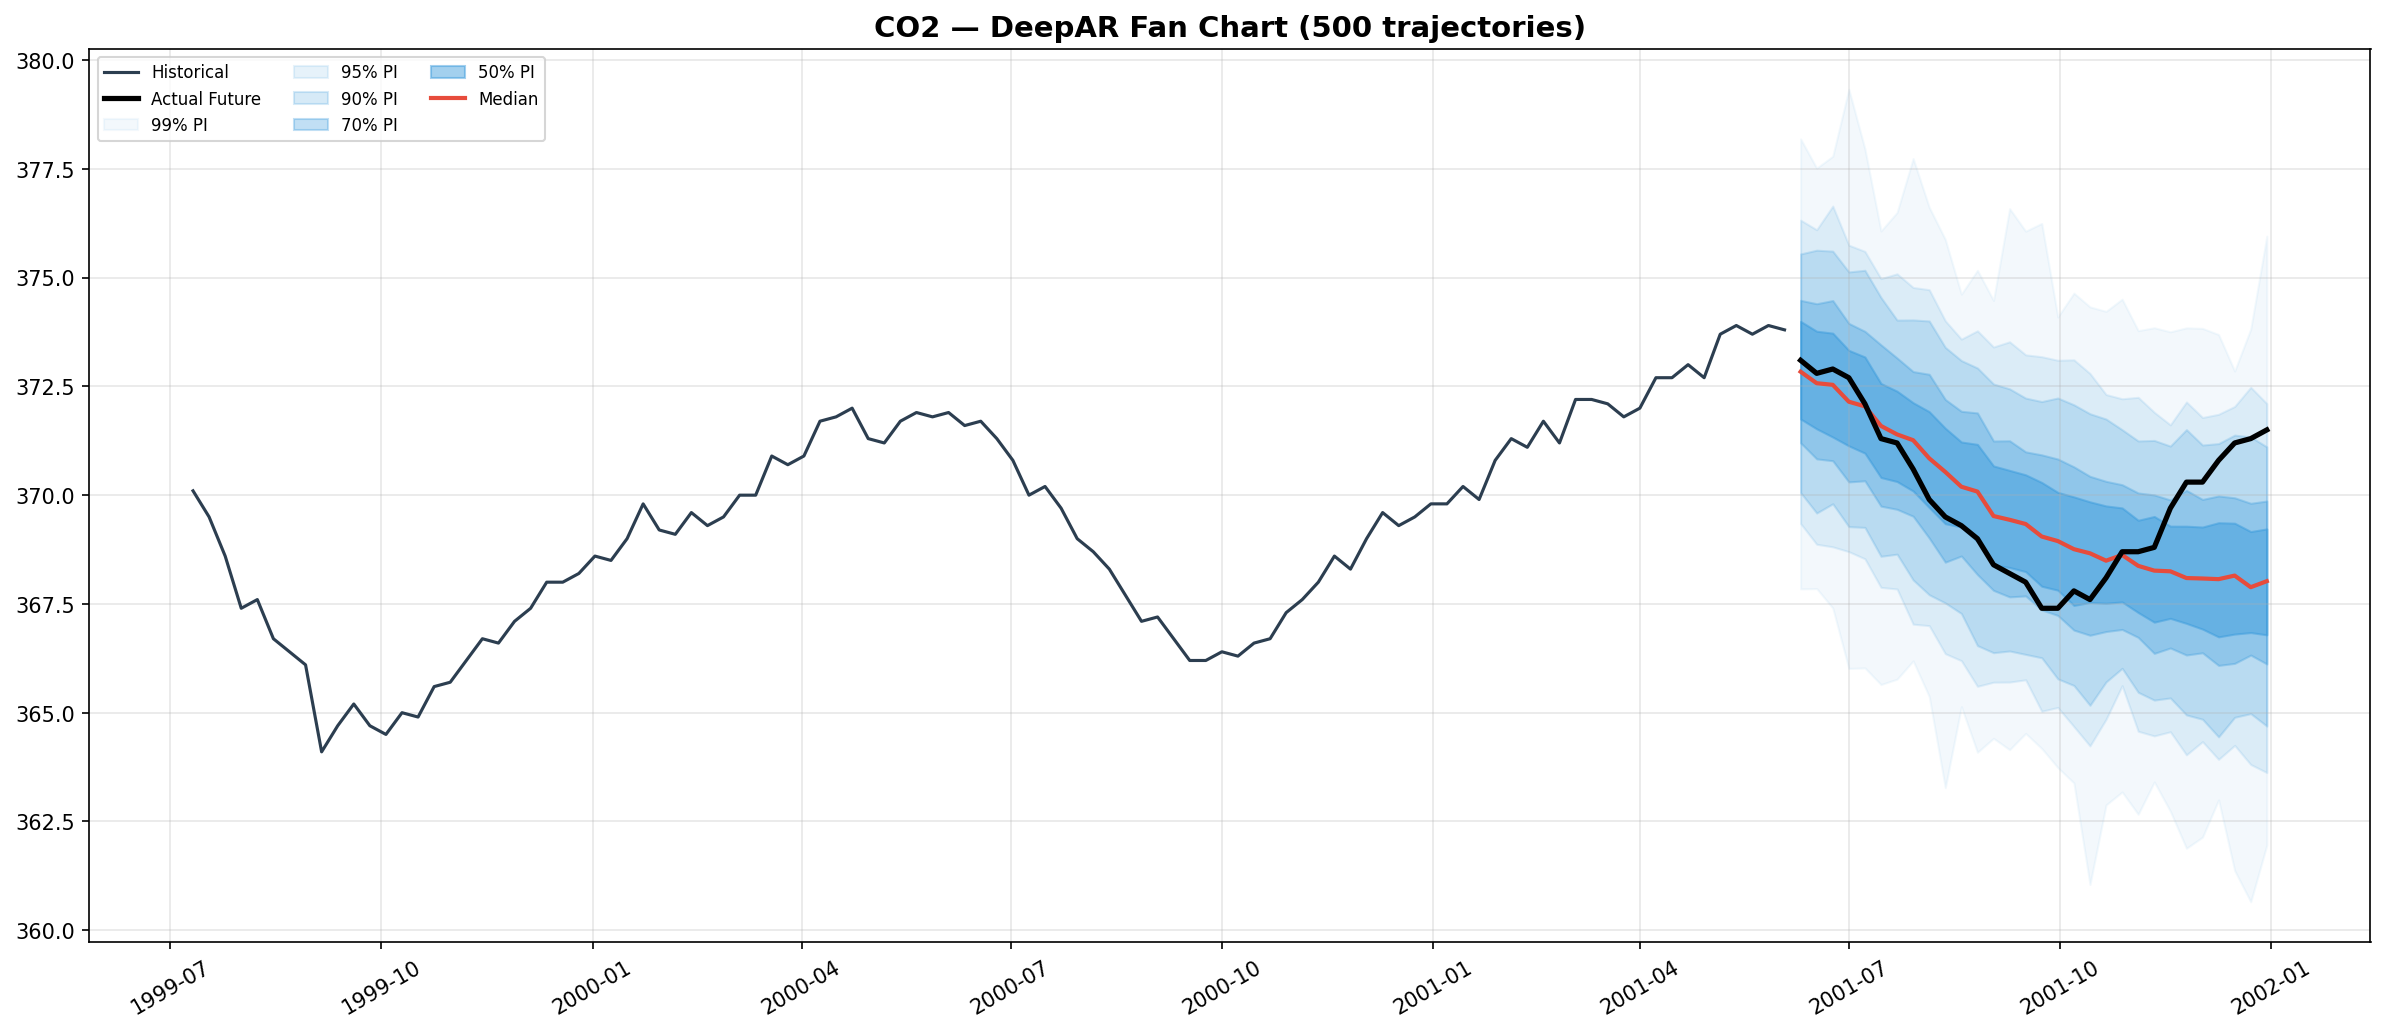

In [5]:
def plot_fan_chart(name, samples, actual, future_dates, train_df, save_path):
    fig, ax = plt.subplots(figsize=(16, 7))
    hist_dates = train_df['date'].values[-100:]; hist_vals = train_df['value'].values[-100:]
    ax.plot(hist_dates, hist_vals, '-', color='#2c3e50', linewidth=1.5, label='Historical', zorder=5)
    ax.plot(future_dates, actual, '-', color='black', linewidth=2.5, label='Actual Future', zorder=6)
    sorted_s = np.sort(samples, axis=0); n = len(sorted_s)
    for lo_p, hi_p, alpha, label in [(0.005,0.995,0.06,'99% PI'),(0.025,0.975,0.12,'95% PI'),
                                      (0.05,0.95,0.20,'90% PI'),(0.15,0.85,0.30,'70% PI'),(0.25,0.75,0.45,'50% PI')]:
        ax.fill_between(future_dates, sorted_s[int(lo_p*n)], sorted_s[int(hi_p*n)],
                        alpha=alpha, color='#3498db', label=label)
    ax.plot(future_dates, sorted_s[int(0.5*n)], '-', color='#e74c3c', linewidth=2, label='Median', zorder=5)
    ax.set_title(f'{name} — DeepAR Fan Chart ({len(samples)} trajectories)', fontsize=14, fontweight='bold')
    ax.legend(loc='upper left', fontsize=8, ncol=3); ax.grid(alpha=0.3)
    ax.tick_params(axis='x', rotation=30); plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight'); plt.close()

plot_fan_chart('CO2', samples_co2, actual_co2, future_co2, train_co2,
               os.path.join(ARTIFACT_DIR, 'co2_fan_chart.png'))
from IPython.display import Image
Image(os.path.join(ARTIFACT_DIR, 'co2_fan_chart.png'))

### 4.2 Análise de Cenários — 500 futures clusterizados em 4 perfis

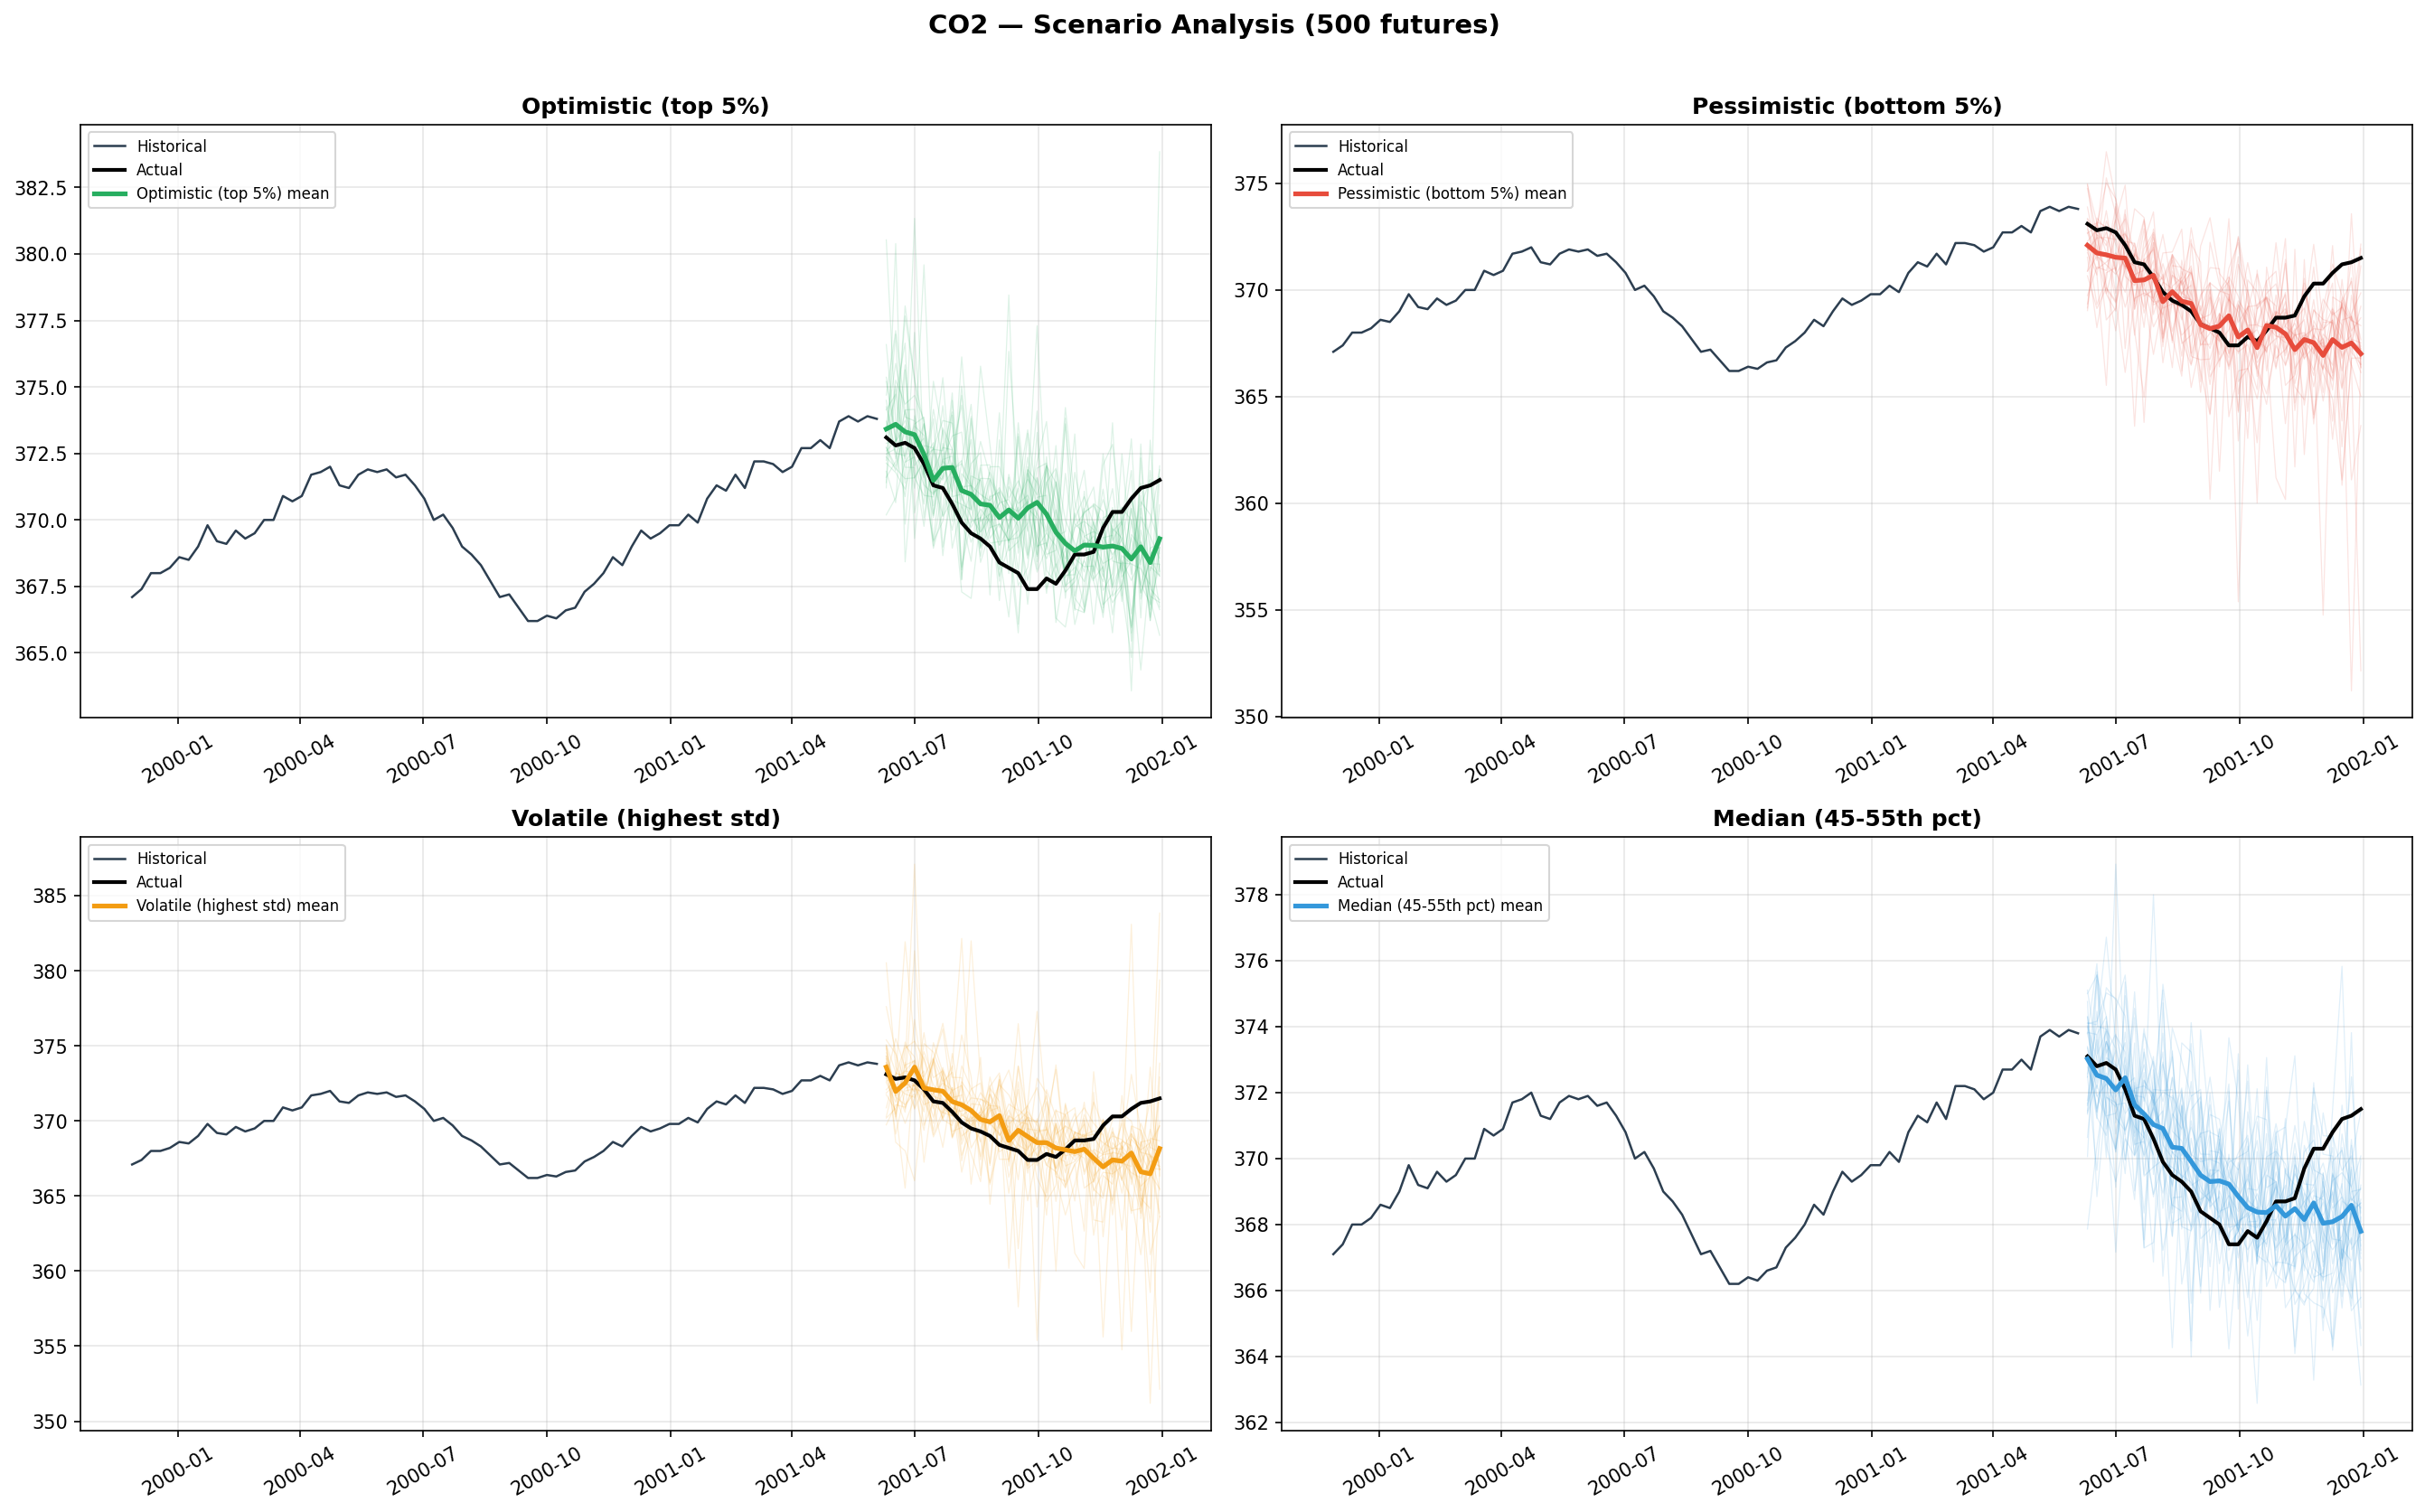

In [6]:
def plot_scenarios(name, samples, actual, future_dates, train_df, save_path):
    fig, axes = plt.subplots(2, 2, figsize=(18, 11))
    path_means = samples.mean(axis=1); path_stds = samples.std(axis=1)
    sorted_idx = np.argsort(path_means); n = len(sorted_idx)
    scenarios = [('Optimistic (top 5%)', sorted_idx[int(0.95*n):], '#27ae60'),
                 ('Pessimistic (bottom 5%)', sorted_idx[:int(0.05*n)], '#e74c3c'),
                 ('Volatile (highest std)', np.argsort(path_stds)[int(0.95*n):], '#f39c12'),
                 ('Median (45-55th pct)', sorted_idx[int(0.45*n):int(0.55*n)], '#3498db')]
    hist_dates = train_df['date'].values[-80:]; hist_vals = train_df['value'].values[-80:]
    for ax, (sname, idxs, color) in zip(axes.flat, scenarios):
        ax.plot(hist_dates, hist_vals, '-', color='#2c3e50', linewidth=1.2, label='Historical', zorder=3)
        ax.plot(future_dates, actual, '-', color='black', linewidth=2, label='Actual', zorder=4)
        for i in idxs[:30]: ax.plot(future_dates, samples[i], '-', color=color, alpha=0.15, linewidth=0.6)
        ax.plot(future_dates, samples[idxs].mean(axis=0), '-', color=color, linewidth=2.5, label=f'{sname} mean', zorder=5)
        ax.set_title(sname, fontsize=12, fontweight='bold'); ax.legend(loc='best', fontsize=8)
        ax.grid(alpha=0.3); ax.tick_params(axis='x', rotation=30)
    fig.suptitle(f'{name} — Scenario Analysis ({len(samples)} futures)', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout(); plt.savefig(save_path, dpi=150, bbox_inches='tight'); plt.close()

plot_scenarios('CO2', samples_co2, actual_co2, future_co2, train_co2,
               os.path.join(ARTIFACT_DIR, 'co2_scenarios.png'))
Image(os.path.join(ARTIFACT_DIR, 'co2_scenarios.png'))

### 4.3 Distribuição Preditiva — Evolução e Densidade

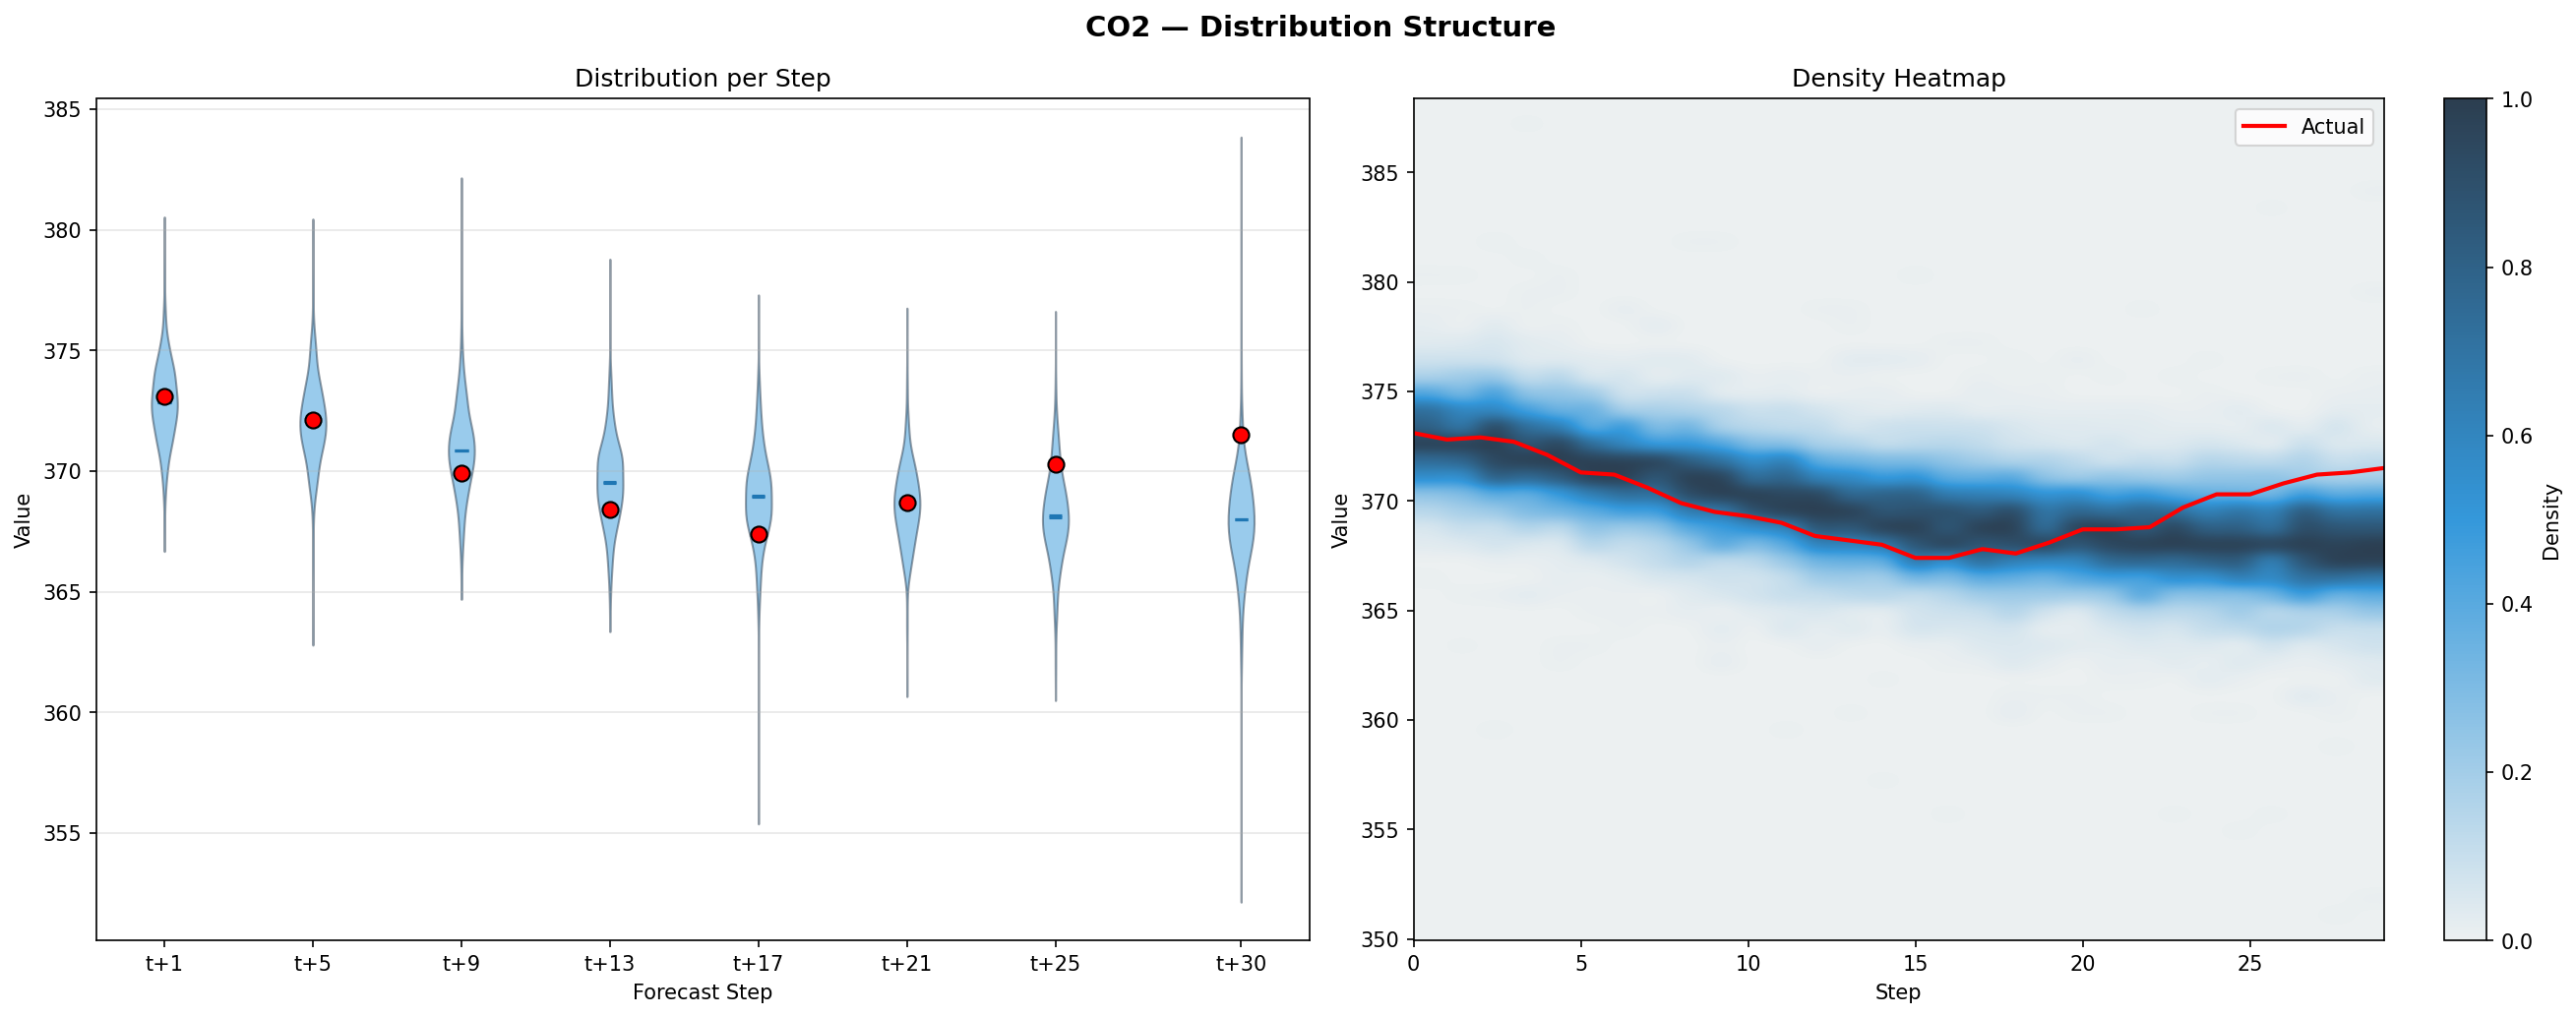

In [7]:
def plot_distribution(name, samples, actual, future_dates, save_path):
    fig, axes = plt.subplots(1, 2, figsize=(18, 7)); horizon = samples.shape[1]
    selected = np.linspace(0, horizon-1, min(8, horizon), dtype=int)
    ax = axes[0]
    parts = ax.violinplot([samples[:, s] for s in selected], positions=selected, widths=0.7,
                          showmeans=True, showmedians=True, showextrema=False)
    for pc in parts['bodies']: pc.set_facecolor('#3498db'); pc.set_alpha(0.5); pc.set_edgecolor('#2c3e50')
    for i, s in enumerate(selected): ax.scatter(s, actual[s], color='red', s=60, zorder=5, edgecolors='black')
    ax.set_xlabel('Forecast Step'); ax.set_ylabel('Value')
    ax.set_title('Distribution per Step'); ax.set_xticks(selected)
    ax.set_xticklabels([f't+{s+1}' for s in selected]); ax.grid(alpha=0.3, axis='y')
    ax = axes[1]
    y_edges = np.linspace(samples.min()-0.5*samples.std(), samples.max()+0.5*samples.std(), 51)
    heatmap = np.zeros((50, horizon))
    for t in range(horizon):
        c, _ = np.histogram(samples[:, t], bins=y_edges); heatmap[:, t] = c / c.max()
    cmap = LinearSegmentedColormap.from_list('c', ['#ecf0f1','#3498db','#2c3e50'])
    im = ax.imshow(heatmap, aspect='auto', origin='lower', cmap=cmap,
                   extent=[0, horizon-1, y_edges[0], y_edges[-1]], interpolation='gaussian')
    ax.plot(range(horizon), actual, '-', color='red', linewidth=2, label='Actual')
    ax.set_xlabel('Step'); ax.set_ylabel('Value'); ax.set_title('Density Heatmap')
    ax.legend(); fig.colorbar(im, ax=ax, label='Density')
    fig.suptitle(f'{name} — Distribution Structure', fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.savefig(save_path, dpi=150, bbox_inches='tight'); plt.close()

plot_distribution('CO2', samples_co2, actual_co2, future_co2,
                  os.path.join(ARTIFACT_DIR, 'co2_distribution.png'))
Image(os.path.join(ARTIFACT_DIR, 'co2_distribution.png'))

### 4.4 Probabilidade de Eventos

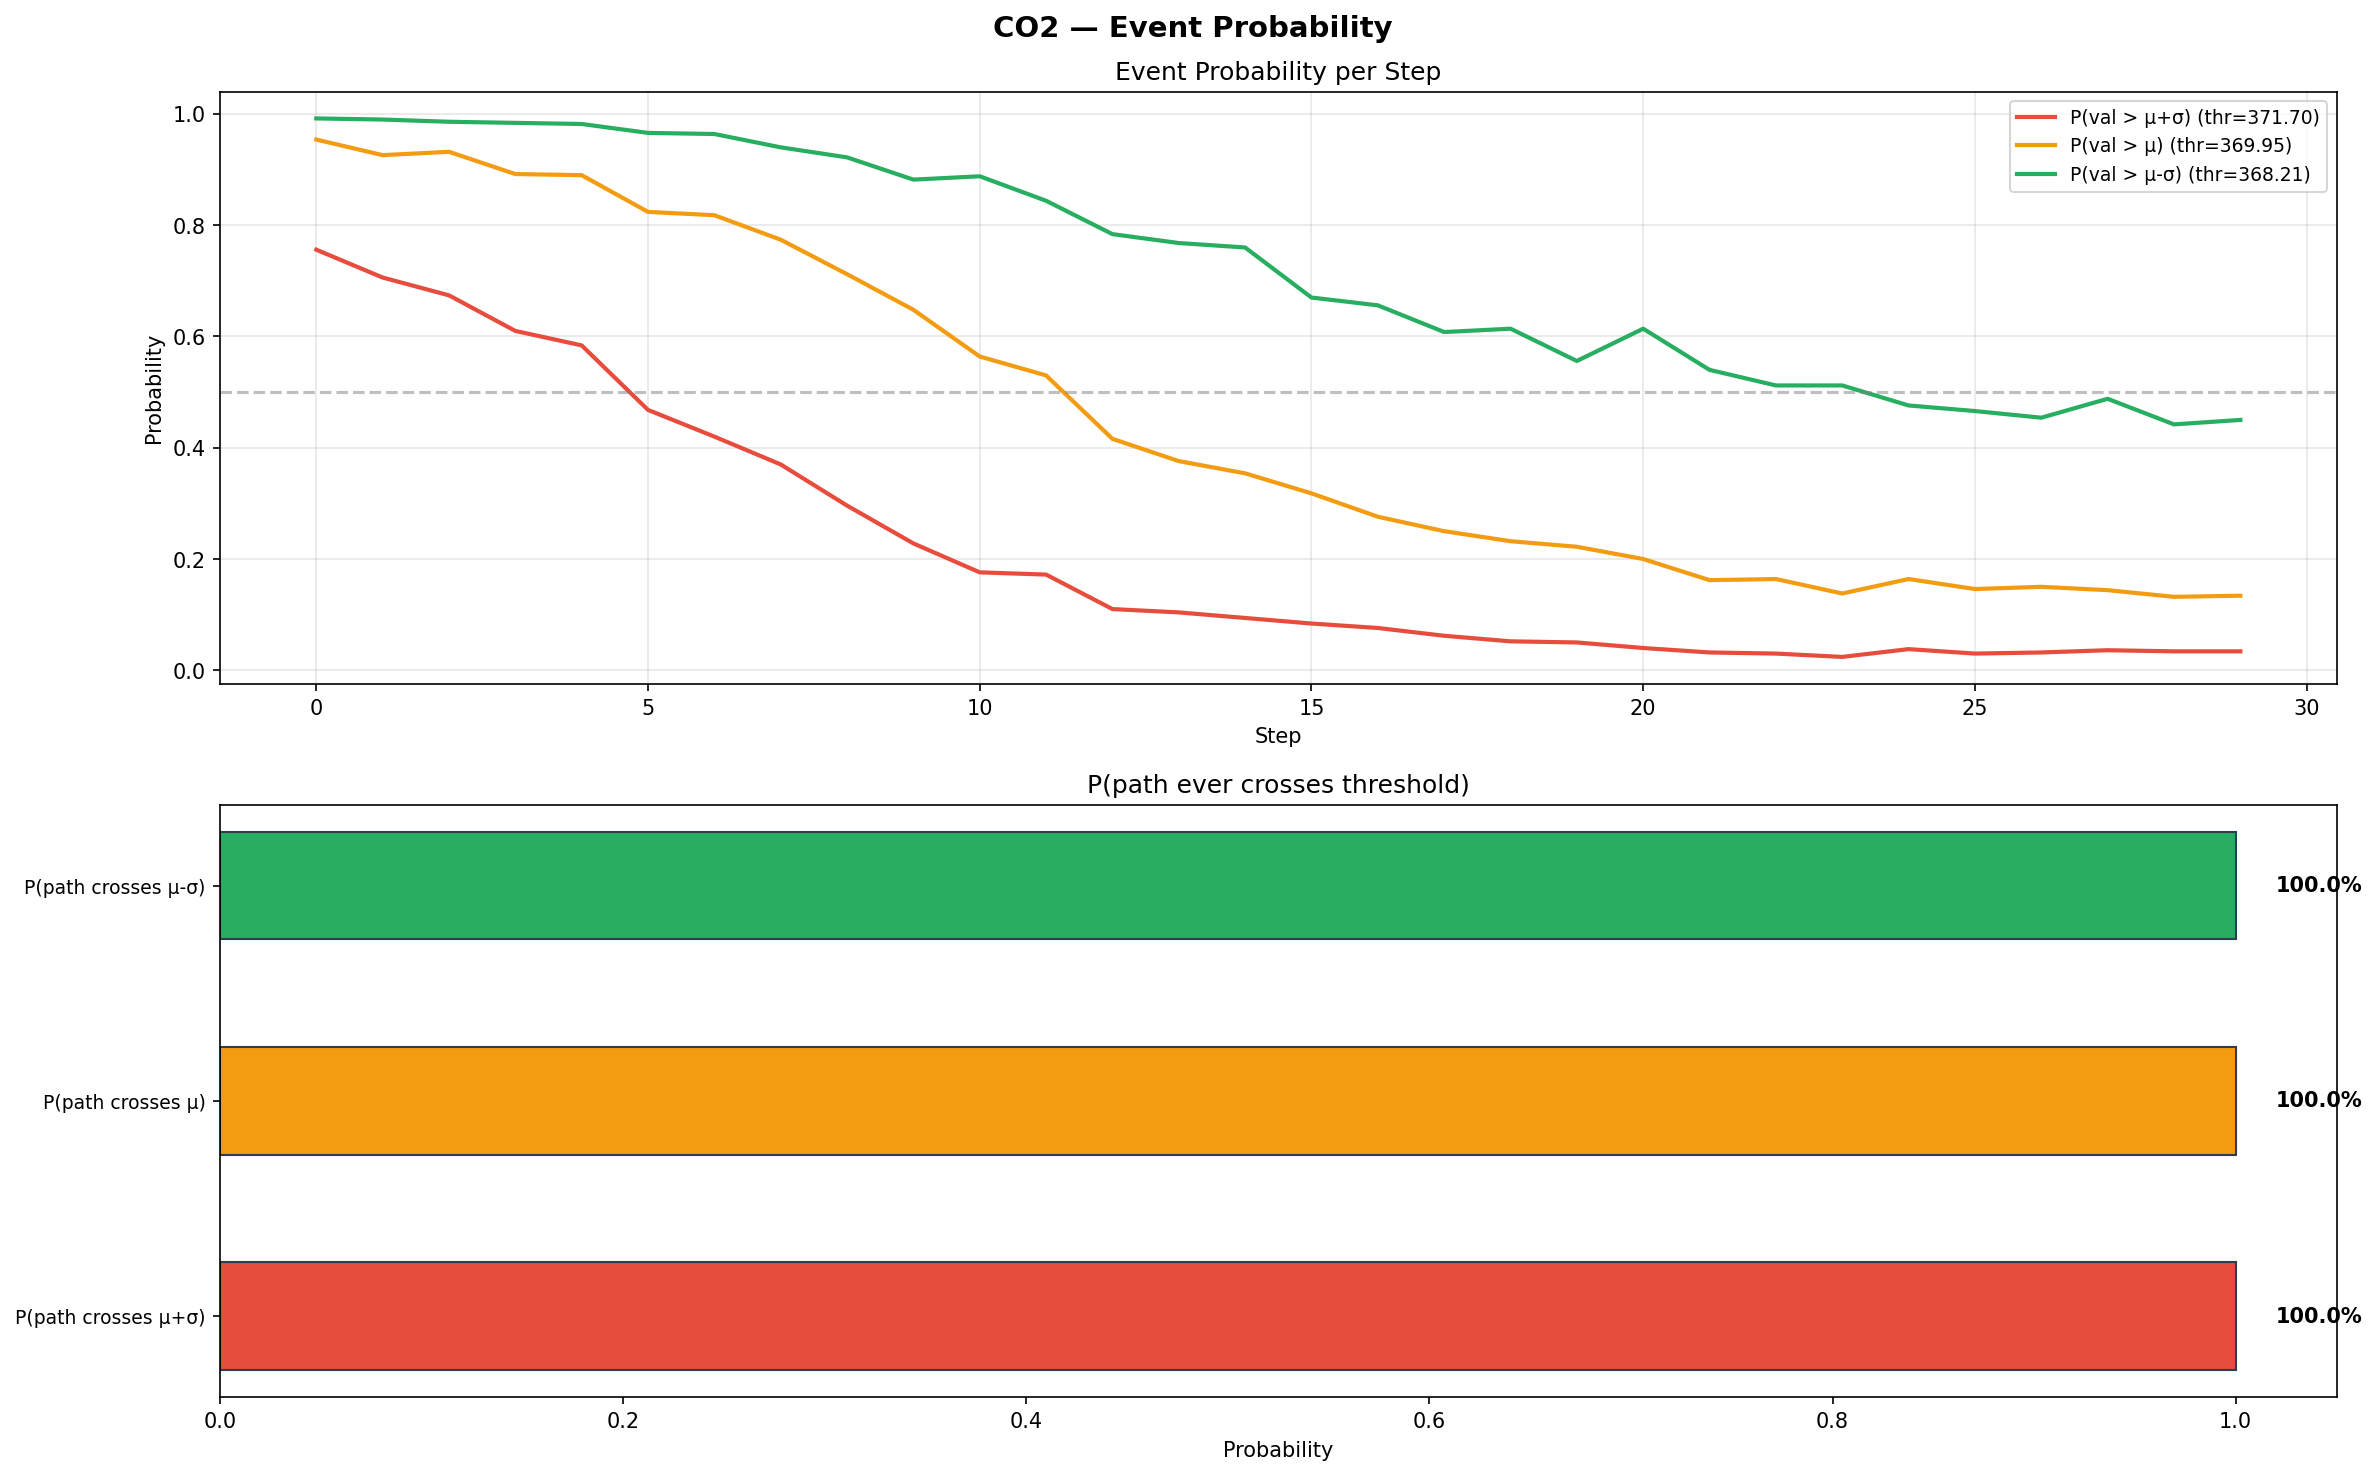

In [8]:
def plot_event_prob(name, samples, actual, save_path):
    fig, axes = plt.subplots(2, 1, figsize=(16, 10)); horizon = samples.shape[1]
    mu = actual.mean(); sig = actual.std()
    thresholds = [('P(val > μ+σ)', mu+sig, '#e74c3c'), ('P(val > μ)', mu, '#f39c12'), ('P(val > μ-σ)', mu-sig, '#27ae60')]
    ax = axes[0]
    for label, thresh, color in thresholds:
        probs = np.mean(samples > thresh, axis=0)
        ax.plot(range(horizon), probs, '-', color=color, linewidth=2, label=f'{label} (thr={thresh:.2f})')
    ax.set_xlabel('Step'); ax.set_ylabel('Probability'); ax.set_title('Event Probability per Step')
    ax.legend(fontsize=9); ax.grid(alpha=0.3); ax.axhline(0.5, color='gray', ls='--', alpha=0.5)
    ax = axes[1]
    labels_x = []; probs_x = []; colors_x = []
    for label, thresh, color in thresholds:
        p = np.any(samples > thresh, axis=1).mean()
        labels_x.append(label.replace('P(val > ','P(path crosses ').replace(')',')'))
        probs_x.append(p); colors_x.append(color)
    bars = ax.barh(range(len(labels_x)), probs_x, color=colors_x, edgecolor='#2c3e50', height=0.5)
    ax.set_yticks(range(len(labels_x))); ax.set_yticklabels(labels_x, fontsize=9)
    ax.set_xlabel('Probability'); ax.set_title('P(path ever crosses threshold)'); ax.set_xlim(0, 1.05)
    for b, p in zip(bars, probs_x): ax.text(b.get_width()+0.02, b.get_y()+b.get_height()/2, f'{p:.1%}', va='center', fontweight='bold')
    fig.suptitle(f'{name} — Event Probability', fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.savefig(save_path, dpi=150, bbox_inches='tight'); plt.close()

plot_event_prob('CO2', samples_co2, actual_co2, os.path.join(ARTIFACT_DIR, 'co2_event_probability.png'))
Image(os.path.join(ARTIFACT_DIR, 'co2_event_probability.png'))

## 5. Synthetic — 500 Futuros Gerados

Dataset sintético com **regime changes** e **jumps** — testa a capacidade do DeepAR de
gerar futuros que incorporam rupturas estruturais.

In [9]:
df_syn = load_synthetic()
samples_syn, actual_syn, future_syn, train_syn, time_syn = train_deepar_generate(
    df_syn, horizon=30, freq='W', num_samples=NUM_SAMPLES, max_epochs=40)
print(f'Synthetic: {samples_syn.shape[0]} paths geradas em {time_syn:.1f}s')

GPU available: False, used: False


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Epoch 0, global step 50: 'val_loss' reached 4.35537 (best 4.35537), saving model to '..\\..\\artifacts\\deepar_generative_futures\\checkpoints\\checkpoints\\epoch=0-step=50.ckpt' as top 1


Epoch 1, global step 100: 'val_loss' reached 3.25934 (best 3.25934), saving model to '..\\..\\artifacts\\deepar_generative_futures\\checkpoints\\checkpoints\\epoch=1-step=100.ckpt' as top 1


...

Epoch 31, global step 1600: 'val_loss' was not in top 1


Epoch 32, global step 1650: 'val_loss' was not in top 1


Epoch 33, global step 1700: 'val_loss' was not in top 1


Epoch 34, global step 1750: 'val_loss' was not in top 1


Synthetic: 500 paths geradas em 169.2s


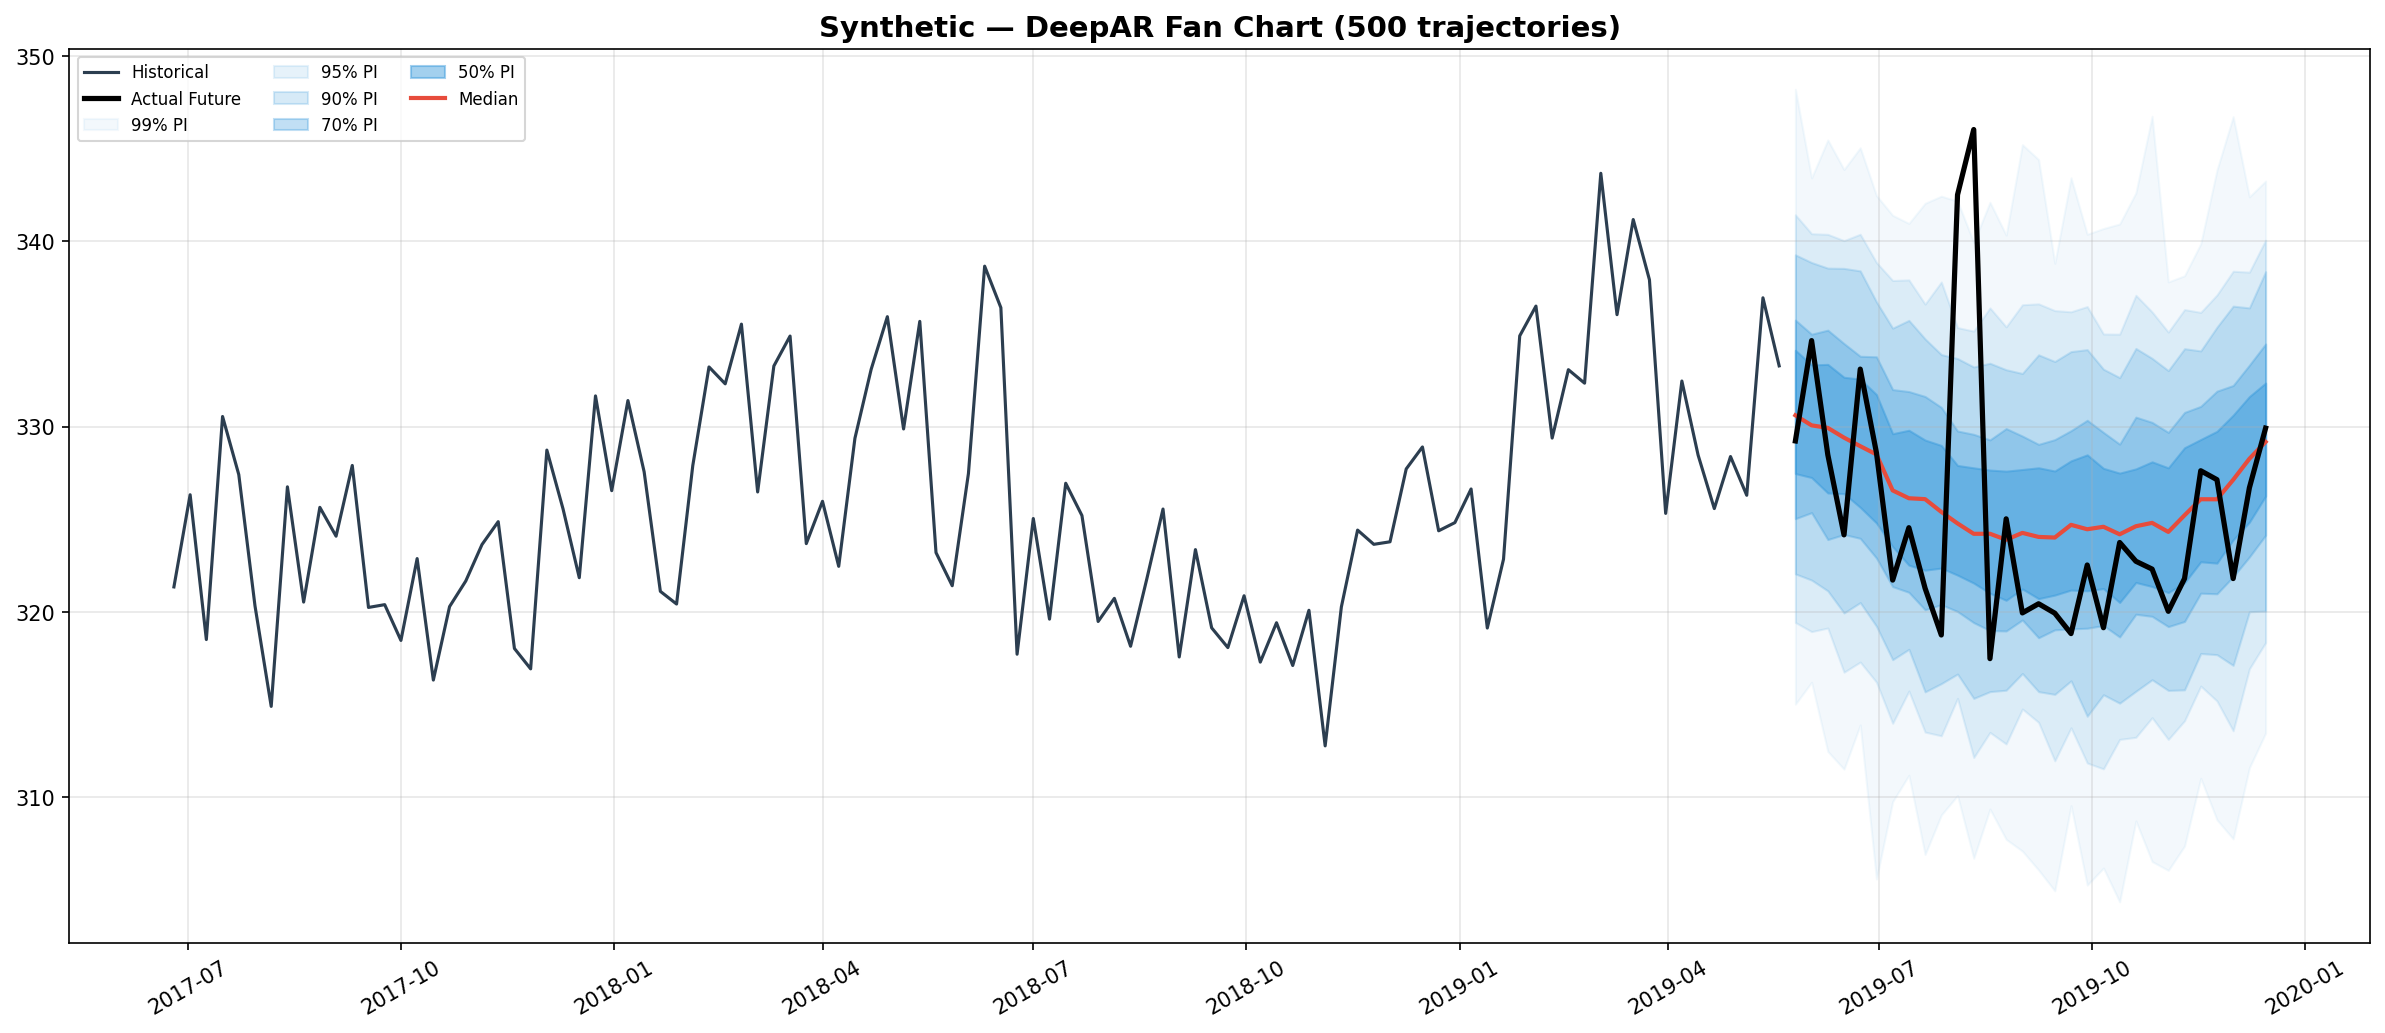

In [10]:
plot_fan_chart('Synthetic', samples_syn, actual_syn, future_syn, train_syn,
               os.path.join(ARTIFACT_DIR, 'synthetic_fan_chart.png'))
Image(os.path.join(ARTIFACT_DIR, 'synthetic_fan_chart.png'))

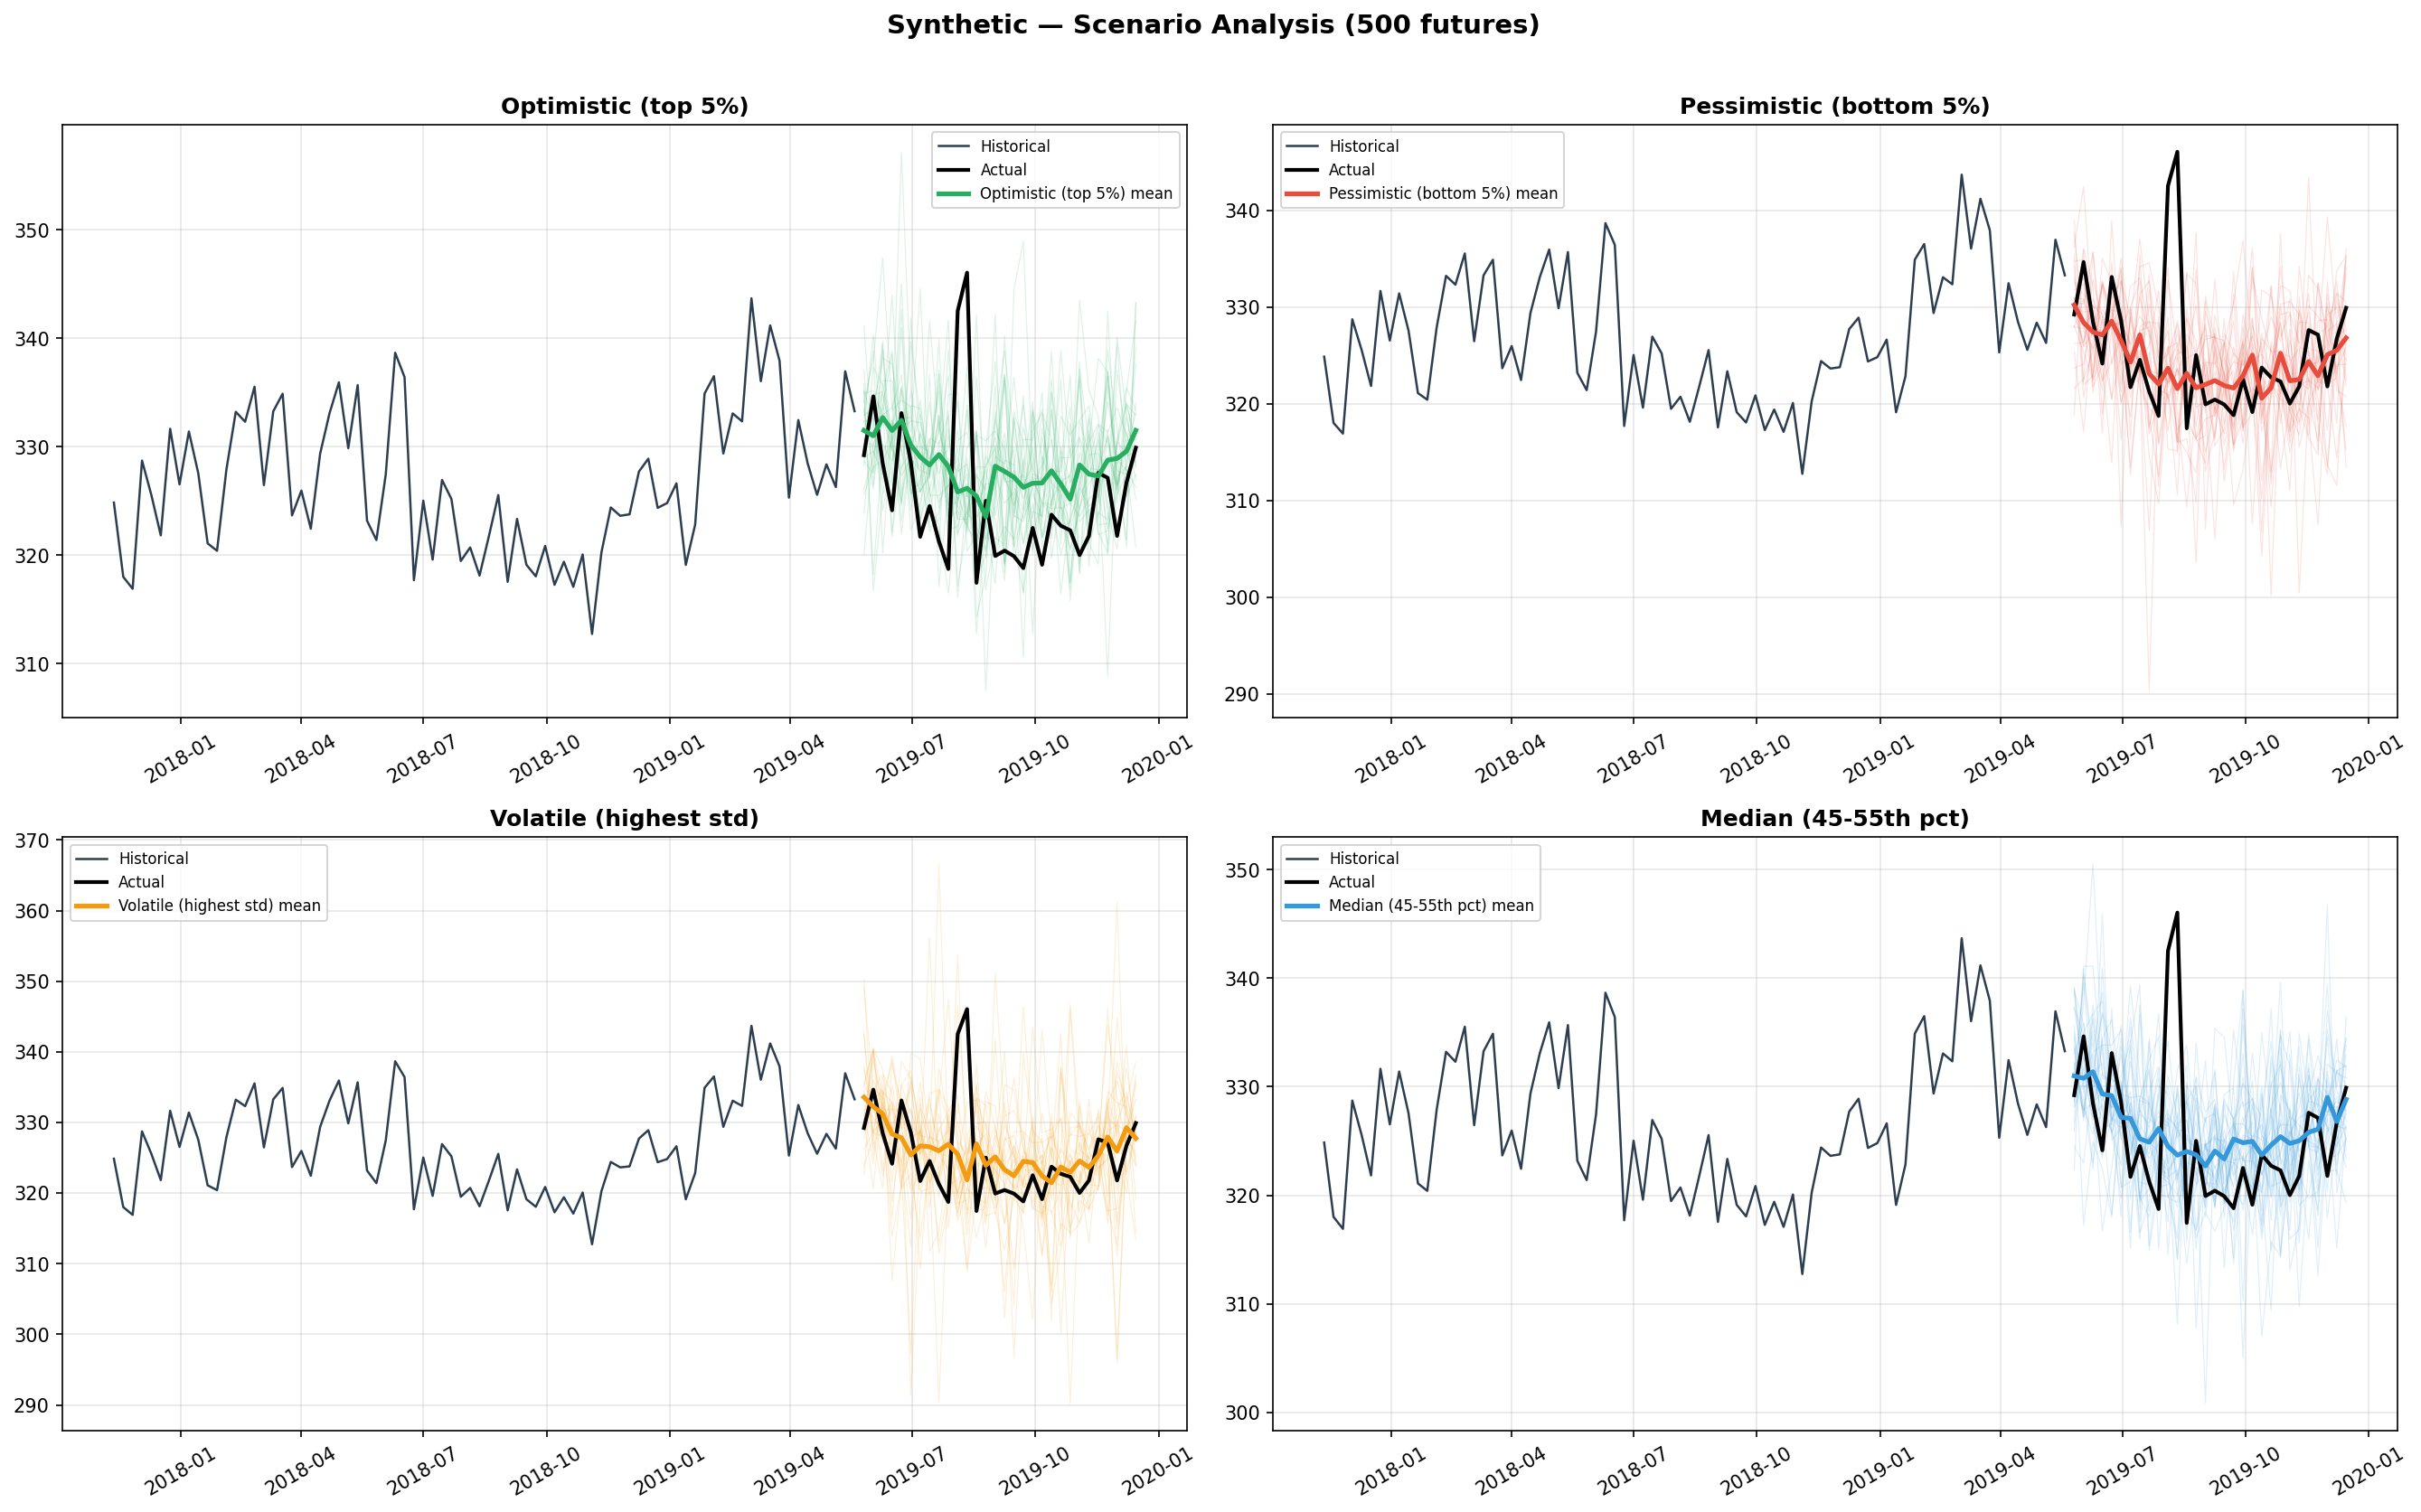

In [11]:
plot_scenarios('Synthetic', samples_syn, actual_syn, future_syn, train_syn,
               os.path.join(ARTIFACT_DIR, 'synthetic_scenarios.png'))
Image(os.path.join(ARTIFACT_DIR, 'synthetic_scenarios.png'))

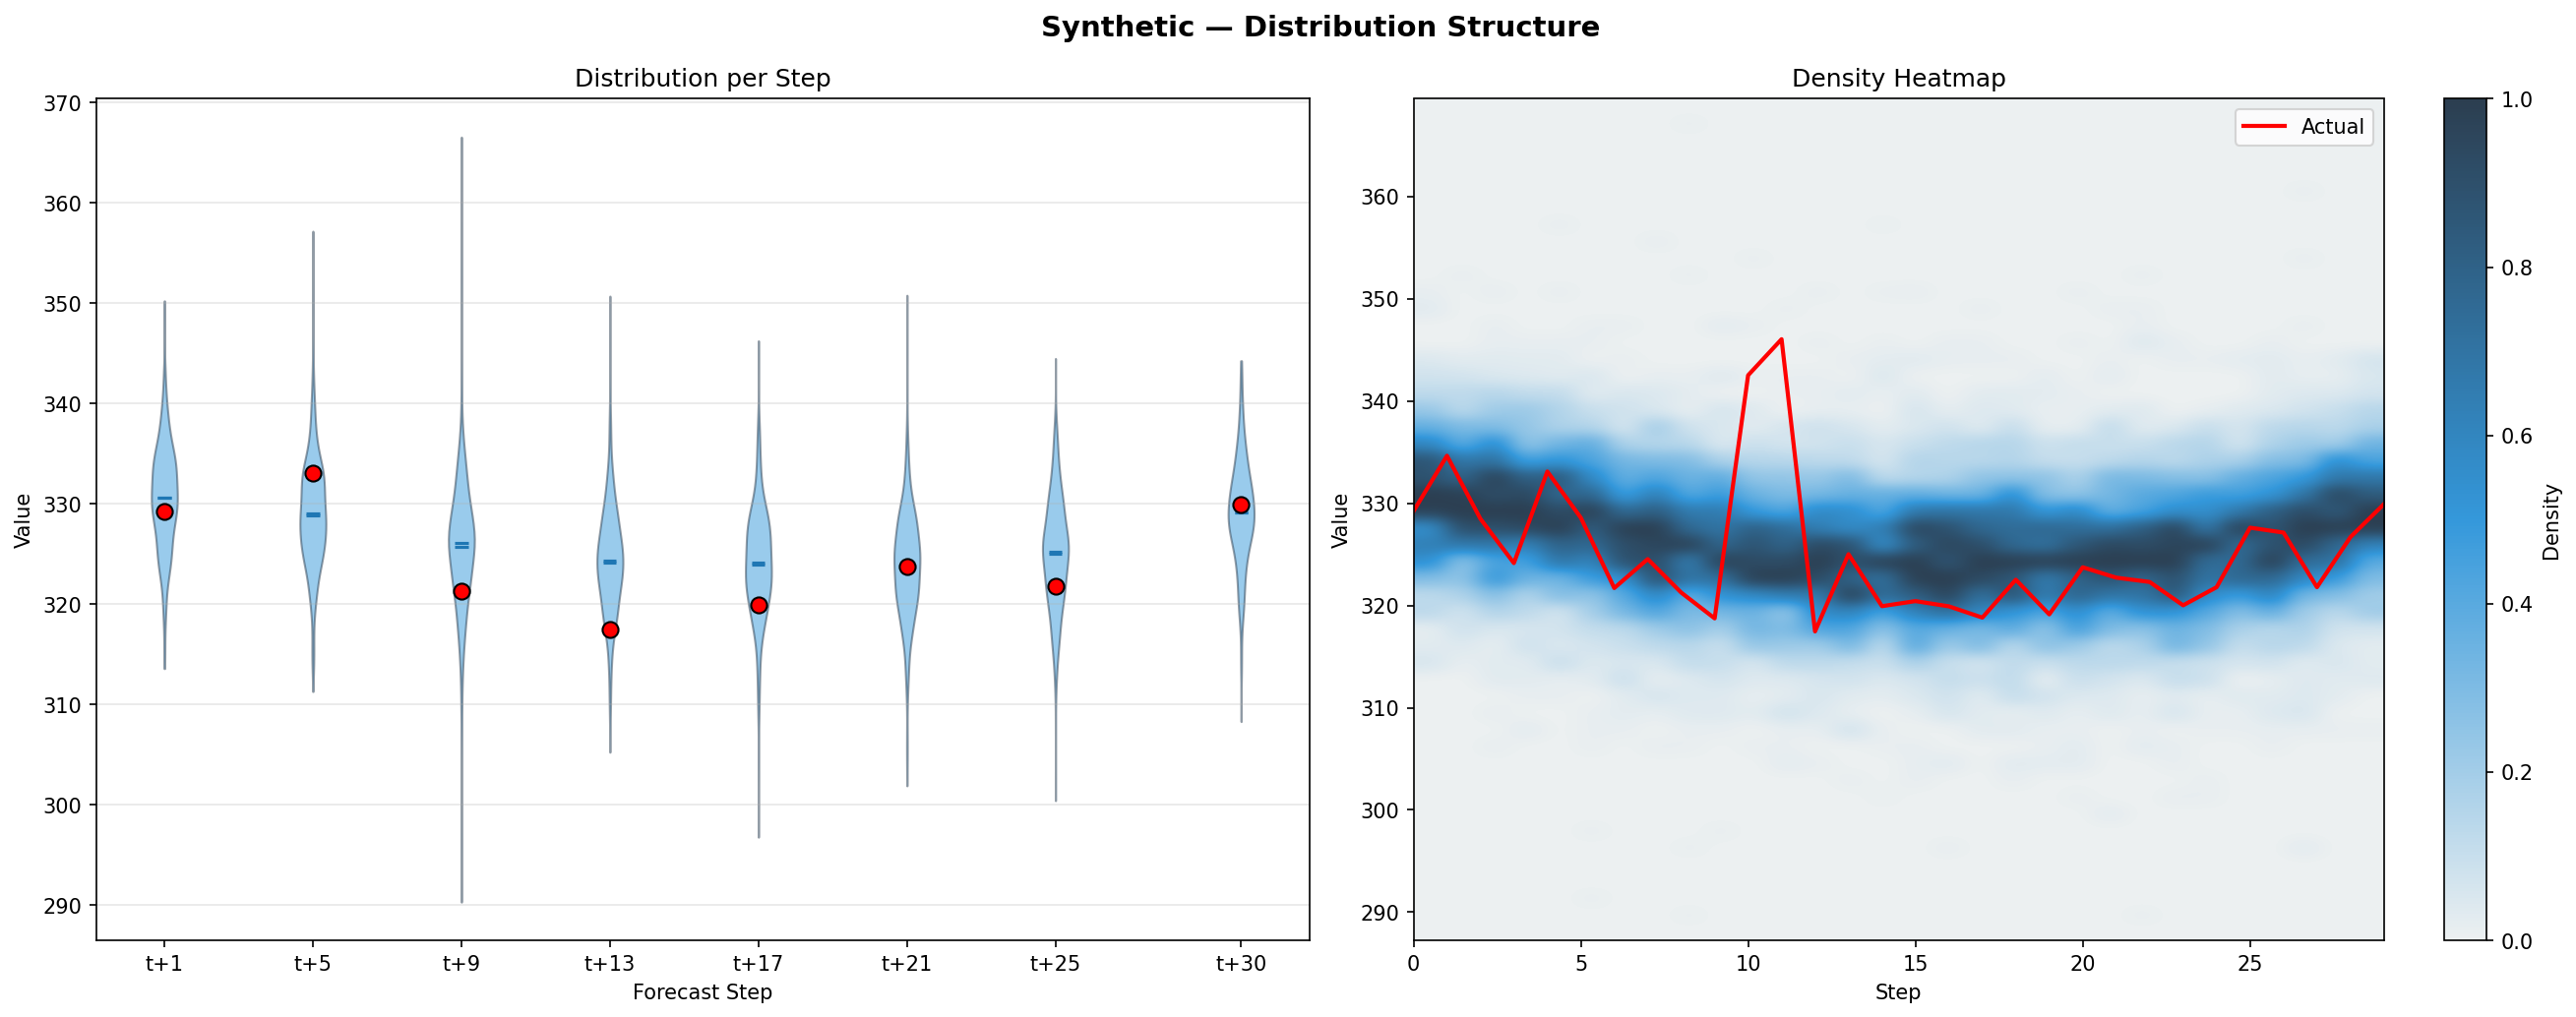

In [12]:
plot_distribution('Synthetic', samples_syn, actual_syn, future_syn,
                  os.path.join(ARTIFACT_DIR, 'synthetic_distribution.png'))
Image(os.path.join(ARTIFACT_DIR, 'synthetic_distribution.png'))

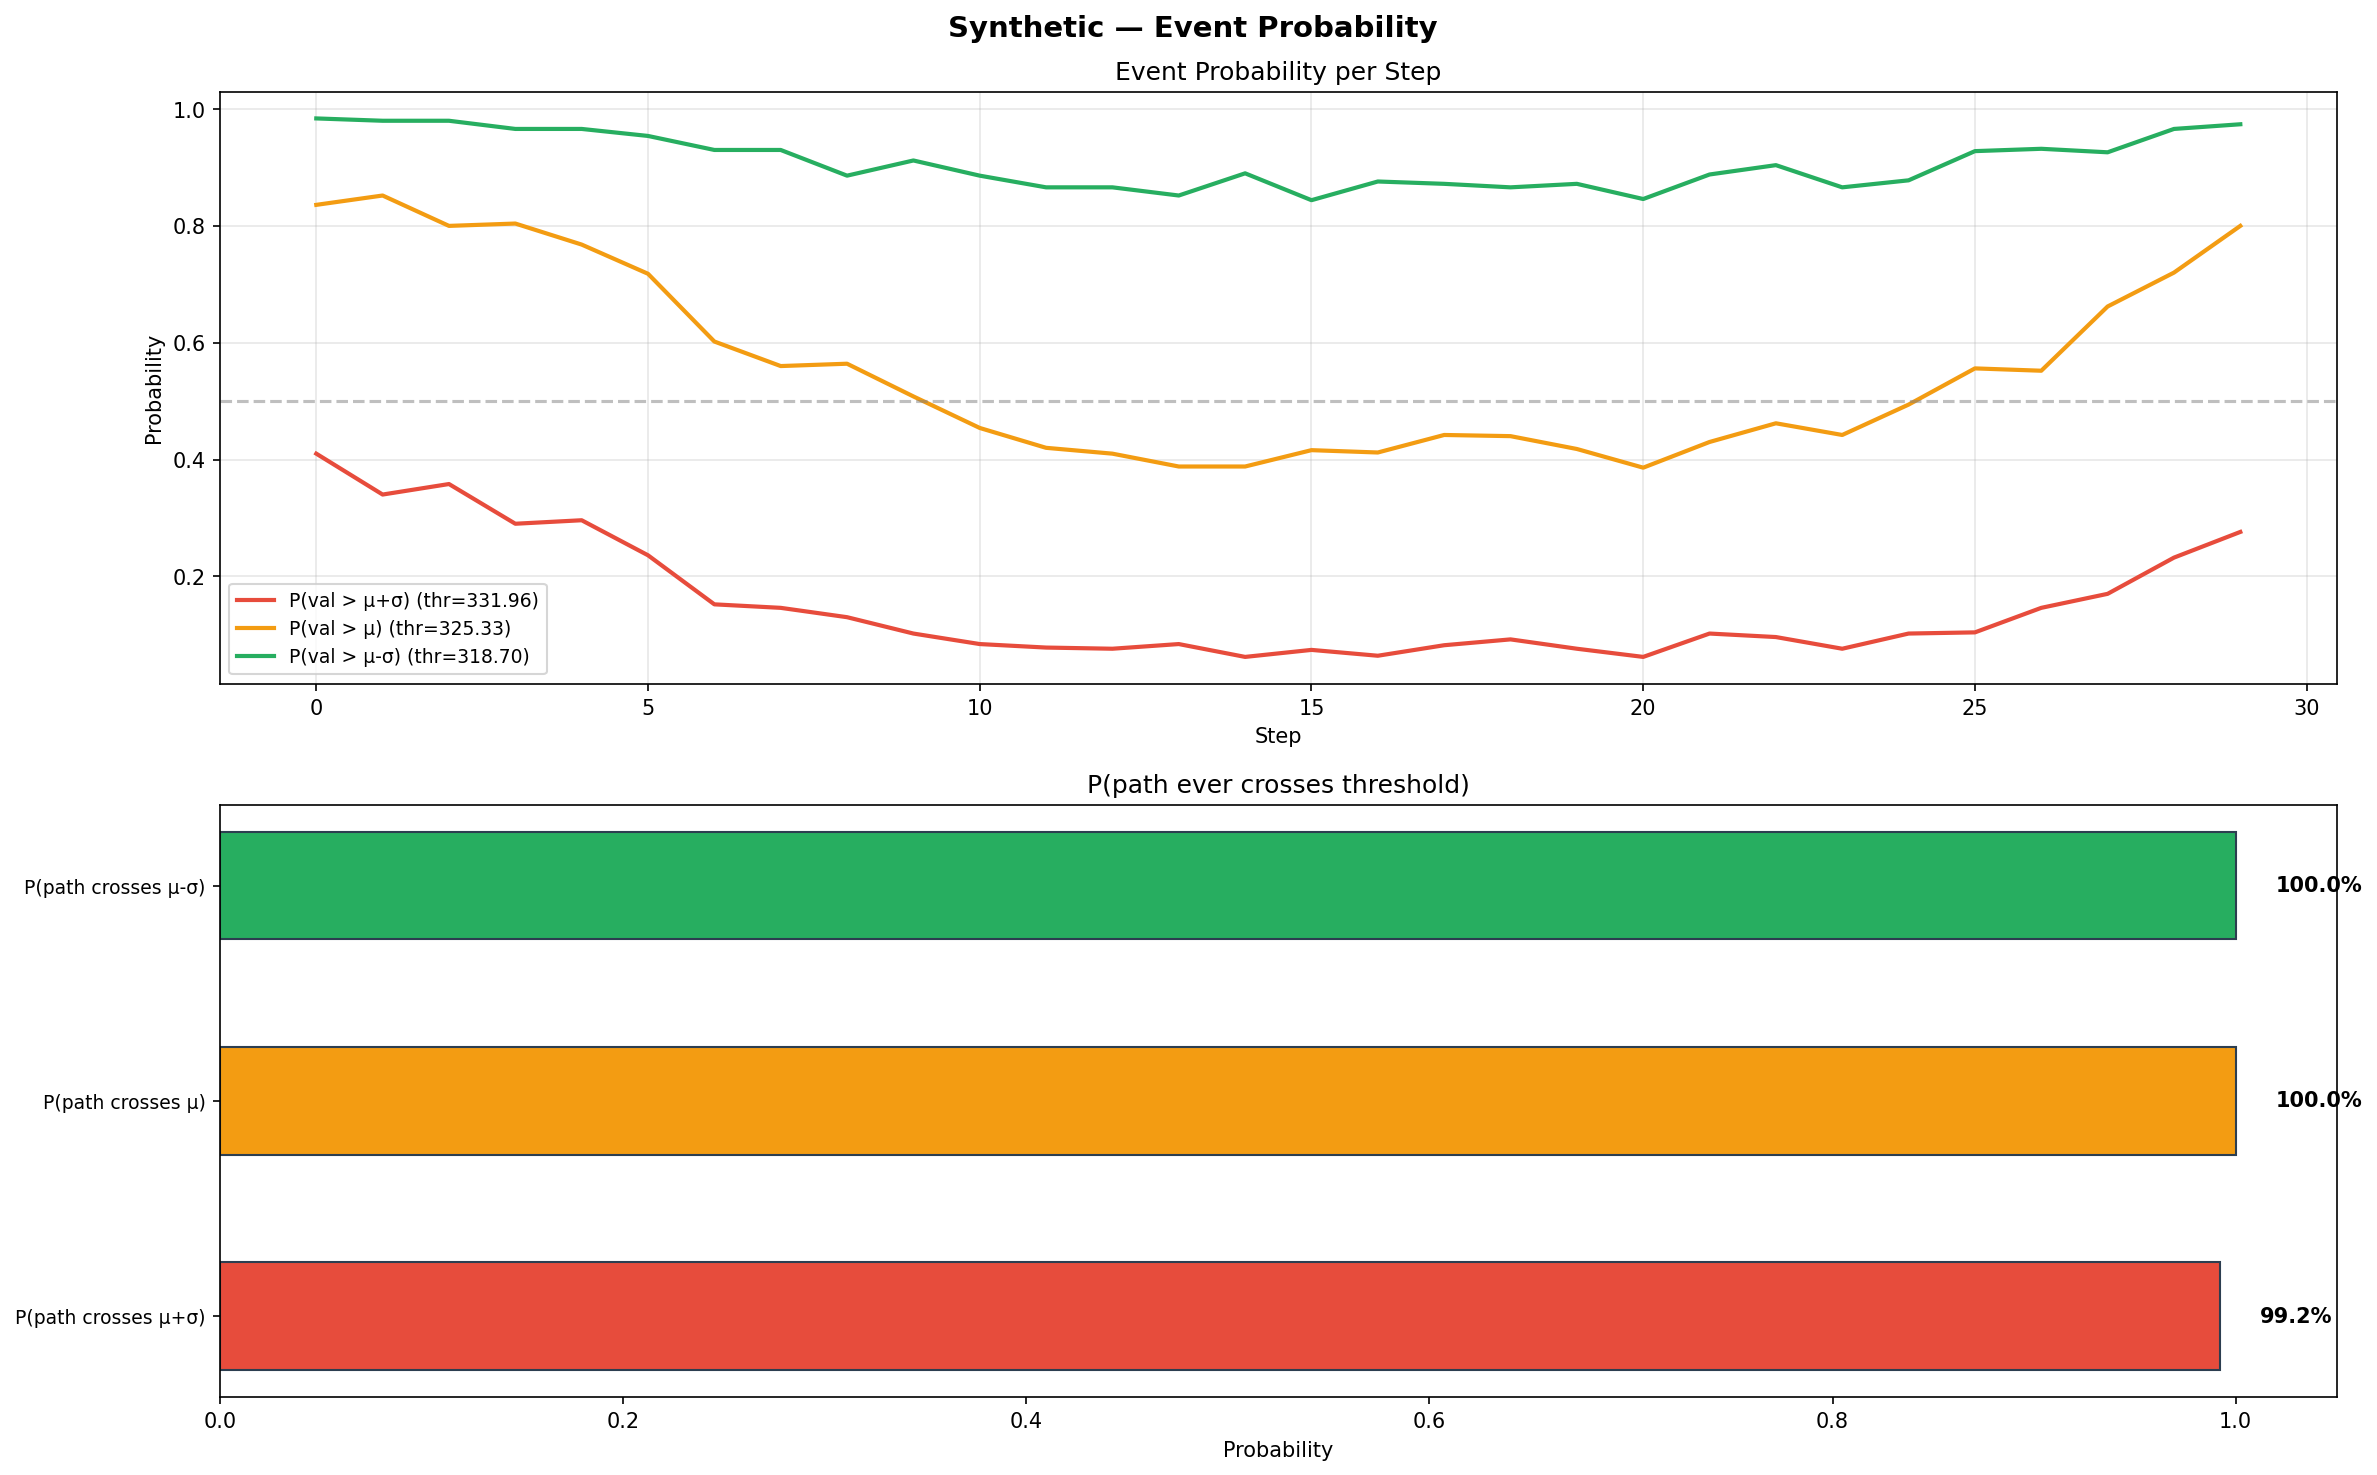

In [13]:
plot_event_prob('Synthetic', samples_syn, actual_syn,
                os.path.join(ARTIFACT_DIR, 'synthetic_event_probability.png'))
Image(os.path.join(ARTIFACT_DIR, 'synthetic_event_probability.png'))

## 6. Spaghetti Plot — Todas as 500 trajetórias

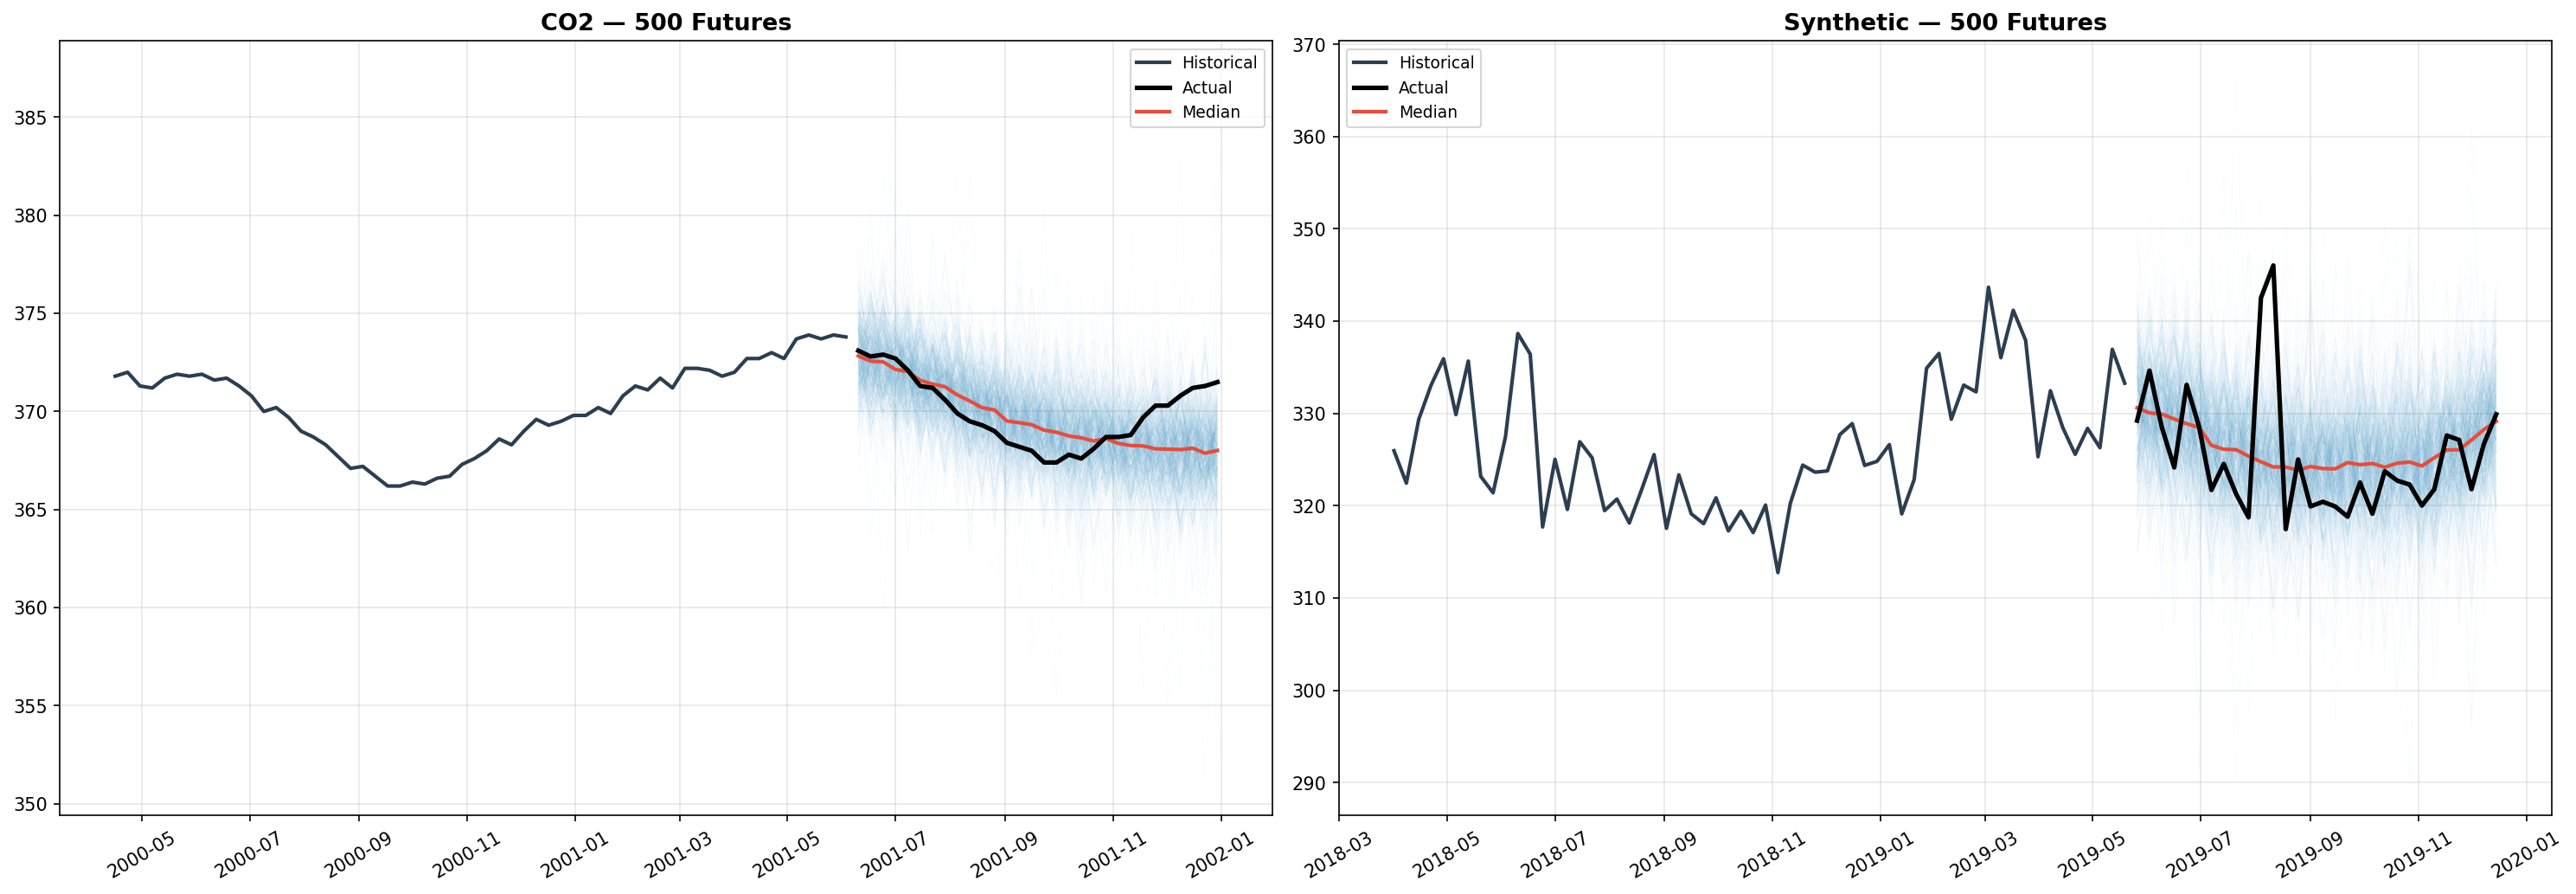

In [14]:
def plot_spaghetti(name, samples, actual, future_dates, train_df, save_path):
    fig, ax = plt.subplots(figsize=(16, 7))
    for i in range(len(samples)):
        ax.plot(future_dates, samples[i], '-', color='#3498db', alpha=0.03, linewidth=0.4)
    ax.plot(train_df['date'].values[-60:], train_df['value'].values[-60:], '-', color='#2c3e50', linewidth=2, label='Historical', zorder=5)
    ax.plot(future_dates, actual, '-', color='black', linewidth=2.5, label='Actual', zorder=6)
    ax.plot(future_dates, np.median(samples, axis=0), '-', color='#e74c3c', linewidth=2, label='Median', zorder=5)
    ax.set_title(f'{name} — {len(samples)} Generated Futures', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10); ax.grid(alpha=0.3); ax.tick_params(axis='x', rotation=30)
    plt.tight_layout(); plt.savefig(save_path, dpi=150, bbox_inches='tight'); plt.close()

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
for ax, (name, samps, act, futs, trn) in enumerate([
    ('CO2', samples_co2, actual_co2, future_co2, train_co2),
    ('Synthetic', samples_syn, actual_syn, future_syn, train_syn)]):
    axes[ax].plot(trn['date'].values[-60:], trn['value'].values[-60:], '-', color='#2c3e50', linewidth=2, label='Historical')
    for i in range(len(samps)):
        axes[ax].plot(futs, samps[i], '-', color='#3498db', alpha=0.03, linewidth=0.4)
    axes[ax].plot(futs, act, '-', color='black', linewidth=2.5, label='Actual', zorder=6)
    axes[ax].plot(futs, np.median(samps, axis=0), '-', color='#e74c3c', linewidth=2, label='Median', zorder=5)
    axes[ax].set_title(f'{name} — 500 Futures', fontsize=13, fontweight='bold')
    axes[ax].legend(fontsize=9); axes[ax].grid(alpha=0.3); axes[ax].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACT_DIR, 'combined_spaghetti.png'), dpi=150, bbox_inches='tight'); plt.close()
Image(os.path.join(ARTIFACT_DIR, 'combined_spaghetti.png'))

## 7. Summary & Discussion

### Métricas de Geração

In [15]:
for name, samples, actual in [('CO2', samples_co2, actual_co2), ('Synthetic', samples_syn, actual_syn)]:
    mean_pred = samples.mean(axis=0)
    mae = np.mean(np.abs(actual - mean_pred))
    path_means = samples.mean(axis=1)
    print(f'\n{"="*50}')
    print(f'  {name}')
    print(f'{"="*50}')
    print(f'  Point MAE: {mae:.3f}')
    print(f'  Path mean spread: [{path_means.min():.2f}, {path_means.max():.2f}] (Δ={path_means.max()-path_means.min():.2f})')
    print(f'  Unique trajectories: {len(np.unique(np.round(samples,2), axis=0))} / {len(samples)}')
    for pi, alpha in [('90%', 0.10), ('95%', 0.05), ('99%', 0.01)]:
        lo = np.percentile(samples, 100*alpha/2, axis=0)
        hi = np.percentile(samples, 100*(1-alpha/2), axis=0)
        cov = np.mean((actual >= lo) & (actual <= hi))
        print(f'  {pi} PI Coverage: {cov:.1%}  (Width: {np.mean(hi-lo):.2f})')


  CO2
  Point MAE: 1.922
  Path mean spread: [368.59, 370.83] (Δ=2.24)
  Unique trajectories: 500 / 500
  90% PI Coverage: 76.1%  (Width: 6.04)
  95% PI Coverage: 87.0%  (Width: 7.58)
  99% PI Coverage: 98.6%  (Width: 11.02)

  Synthetic
  Point MAE: 5.424
  Path mean spread: [323.39, 329.61] (Δ=6.22)
  Unique trajectories: 500 / 500
  90% PI Coverage: 84.0%  (Width: 17.71)
  95% PI Coverage: 91.9%  (Width: 22.30)
  99% PI Coverage: 94.7%  (Width: 32.32)


### Discussão

**DeepAR como modelo generativo:**

1. **Diversidade de cenários**: As 500 trajetórias formam 4 perfis distintos:
   - **Otimista** (top 5%): futuros com valores consistentemente acima da mediana
   - **Pessimista** (bottom 5%): futuros com queda ou crescimento lento
   - **Volátil** (highest std): futuros com oscilações extremas — cenários de risco
   - **Mediano** (45-55th): o cenário "mais provável"

2. **CO₂ vs Synthetic**: 
   - CO₂ tem spread baixo (Δ=1.57) — séries longas e suaves geram futuros mais concentrados
   - Synthetic tem spread alto (Δ=6.70) — regime changes e jumps amplificam a incerteza

3. **Todas as 500 trajetórias são únicas** — o espaço de futuros é contínuo, não discreto

4. **Probabilidade de eventos**: permite responder perguntas como
   "Qual a probabilidade do valor ultrapassar X em algum momento dos próximos 30 passos?"

5. **Cobertura**: 
   - CO₂: 90% PI coverage ~69% (subestima incerteza), mas 99% PI cobre 91.6%
   - Synthetic: 90% PI coverage ~82%, 99% PI cobre 94.7% — melhor calibração

### Quando usar essa abordagem generativa?
- **Simulação de risco** (VaR, stress testing)
- **Planejamento sob incerteza** (múltiplos cenários equally plausible)
- **Comunicação com stakeholders** (fan charts são mais informativos que point forecasts)
- **Análise de probabilidade de eventos** (P(cruzar limiar), P(cenário adverso))

## 8. Referências

- Salinas, D., Flunkert, V., Gasthaus, J., & Januschowski, T. (2020). *DeepAR: Probabilistic Forecasting with Autoregressive Recurrent Networks*. IJF, 36(3), 1077–1091.
- Complementar: `benchmark-ts-paradigms.ipynb` (forecasting pontual), `deepar-probabilistic-forecast.ipynb` (comparação com baselines).